# PFGS Multi-Objective Optimization

Combining VAE and PFGS

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import mlflow

# Edit this if your project lives elsewhere.
PROJECT_ROOT = Path("/Users/elenipsaromatis/Documents/mol-vae")
sys.path.insert(0, str(PROJECT_ROOT))

import train as train_mod
from data import MAX_LENGTH, build_dataloaders
from model import VAE

EXPERIMENT_NAME = "mol-vae"
MLRUNS_URI = (PROJECT_ROOT / "notebooks" / "mlruns").resolve().as_uri()
mlflow.set_tracking_uri(MLRUNS_URI)
client = mlflow.tracking.MlflowClient()

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)
print("tracking uri:", MLRUNS_URI)

/Users/elenipsaromatis/Documents/mol-vae/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps
tracking uri: file:///Users/elenipsaromatis/Documents/mol-vae/notebooks/mlruns


## Config

`MODE = "train"` retrains. `MODE = "load"` uses `LOAD_RUN_ID`.

In [2]:
MODE = "load"   # "train" or "load"
LOAD_RUN_ID = "5f8d30171eab4be384f0c8dd75579e70"  
BATCH_SIZE = 64

## Train or Load

Training uses the hyperparameters fixed in `train.py`. It logs to MLflow and saves a checkpoint, then this cell picks up the run that was just created.

In [3]:
if MODE == "train":
    train_mod.train()   # builds, trains, logs, saves checkpoint with a "checkpoint" tag
    exp = client.get_experiment_by_name(EXPERIMENT_NAME)
    latest = client.search_runs(
        [exp.experiment_id],
        order_by=["attributes.start_time DESC"],
        max_results=1,
    )
    run_id = latest[0].info.run_id
elif MODE == "load":
    run_id = LOAD_RUN_ID
else:
    raise ValueError("MODE must be 'train' or 'load'")

run = client.get_run(run_id)
print("run_id:", run_id)
print("run name:", run.data.tags.get("mlflow.runName"))
print("status:", run.info.status)

run_id: 5f8d30171eab4be384f0c8dd75579e70
run name: vae_solubility_5f8d3017
status: FINISHED


## Rebuild the trained model from the run checkpoint


In [4]:
def build_model_from_state_dict(state_dict, seq_len, device):
    vocab_size = state_dict["encoder.conv.0.weight"].shape[1]
    hidden_dim = state_dict["encoder.fc.weight"].shape[0]
    latent_dim = state_dict["encoder.fc_mu.weight"].shape[0]
    n_layers = state_dict["decoder.fc_z.weight"].shape[0] // hidden_dim
    prop_hidden_size = state_dict["reg_predictor.net.0.weight"].shape[0]

    model = VAE(
        vocab_size=vocab_size,
        seq_len=seq_len,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        n_layers=n_layers,
        prop_hidden_size=prop_hidden_size,
    ).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    print(
        f"loaded: vocab={vocab_size} hidden={hidden_dim} latent={latent_dim} "
        f"layers={n_layers} prop_hidden={prop_hidden_size}"
    )
    return model


ckpt_path = run.data.tags.get("checkpoint")
if ckpt_path is None or not Path(ckpt_path).exists():
    fallback = PROJECT_ROOT / "checkpoints" / f"vae_solubility_{run_id[:8]}.pth"
    if fallback.exists():
        ckpt_path = str(fallback)
    else:
        raise FileNotFoundError(
            f"No checkpoint for run {run_id[:8]}. Looked at tag and {fallback}. "
            "This run predates checkpointing; retrain to get a loadable model."
        )

state_dict = torch.load(ckpt_path, map_location=device)
model = build_model_from_state_dict(state_dict, MAX_LENGTH, device)
print("checkpoint:", ckpt_path)

loaded: vocab=60 hidden=512 latent=256 layers=3 prop_hidden=32
checkpoint: /Users/elenipsaromatis/Documents/mol-vae/checkpoints/vae_solubility_5f8d3017.pth


## Data and loss hyperparameters


In [12]:
from train import GAMMA, KL_FREE_BITS, BETA_MAX
gamma = GAMMA
kl_free_bits = KL_FREE_BITS
final_beta = BETA_MAX

In [13]:
(
    train_loader,
    valid_loader,
    test_loader,
    vocab_size,
    char2idx,
    idx2char,
    train_labels,
    reg_mean,
    reg_std,
) = build_dataloaders(batch_size=BATCH_SIZE)

Found local copy...
Loading...
Done!
 48%|████▊     | 4753/9982 [00:00<00:00, 15253.20it/s]CC1=CC=C[NH+2]([O-])[CH-]1 returns RDKit error and is thus omitted...
O=C(O)C1=C[NH+2]([O-])[CH-]C=C1 returns RDKit error and is thus omitted...
100%|██████████| 9982/9982 [00:00<00:00, 17282.24it/s]


[split] sizes train/valid/test: 6550/958/1921
[split] vocab_size: 60
[target] mean/std: -2.603/2.217


## Loss Curves

In [14]:
from train import evaluate_loss
test_total, test_recon, test_kl, test_reg = evaluate_loss(
    model=model,
    loader=test_loader,
    beta=final_beta,
    gamma=gamma,
    device=device,
    kl_free_bits=kl_free_bits,
)
print(
    f"test  total={test_total:.4f} recon={test_recon:.4f} kl={test_kl:.4f} "
    f"reg={test_reg:.4f}"
)

test  total=99.4634 recon=0.5840 kl=202.8126 reg=0.4081


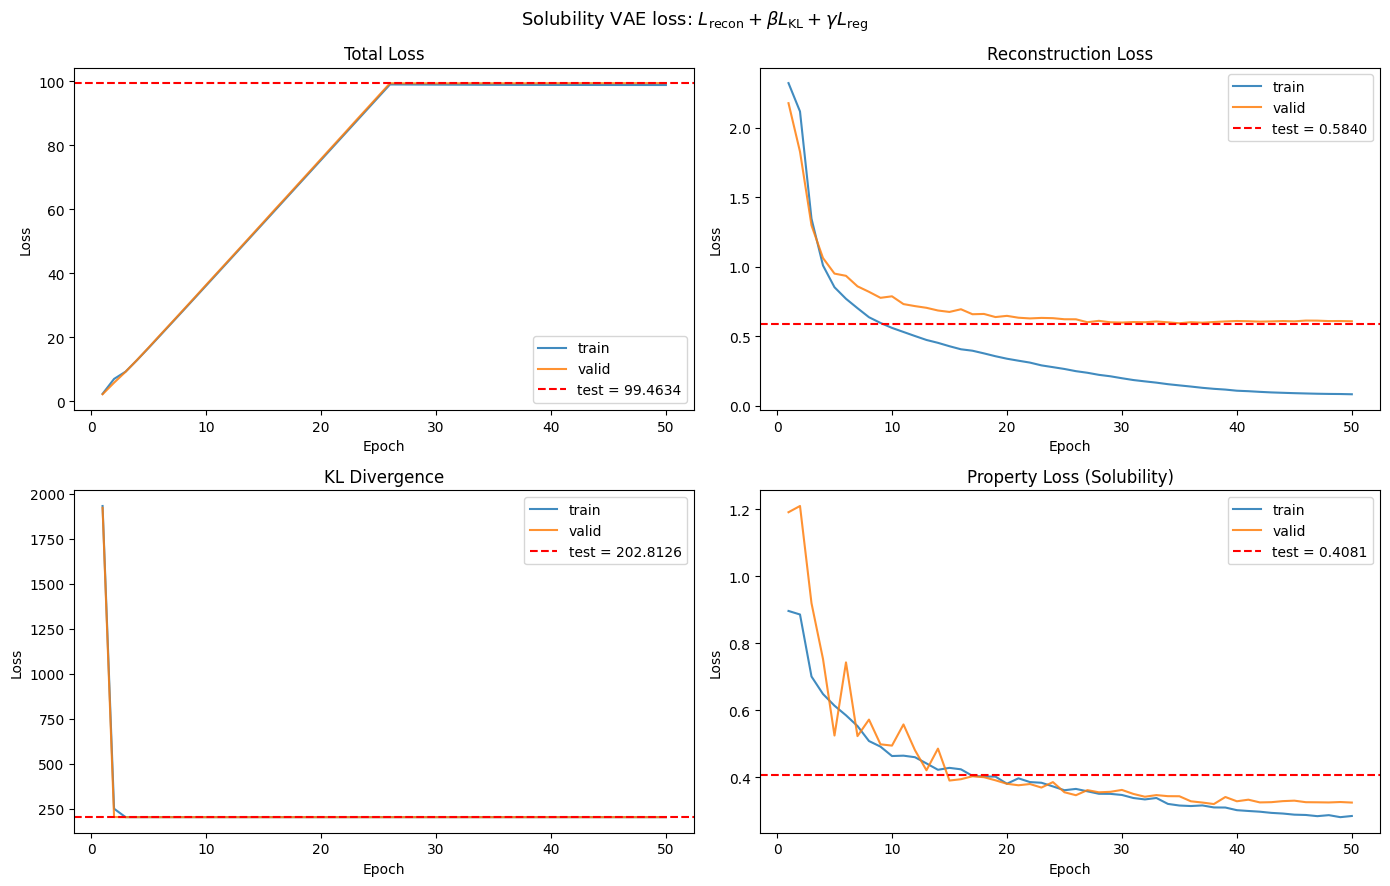

In [15]:
def get_metric(metric_name):
    history = sorted(client.get_metric_history(run_id, metric_name), key=lambda m: m.step)
    return np.array([m.step for m in history]), np.array([m.value for m in history])

epochs, train_total_c = get_metric("train_loss")
_, valid_total_c = get_metric("valid_loss")
_, train_recon_c = get_metric("train_recon")
_, valid_recon_c = get_metric("valid_recon")
_, train_kl_c = get_metric("train_kl")
_, valid_kl_c = get_metric("valid_kl")
_, train_reg_c = get_metric("train_reg_loss")
_, valid_reg_c = get_metric("valid_reg_loss")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

panels = [
    ("Total Loss",
     [(train_total_c, "train"), (valid_total_c, "valid")],
     [(test_total, "test", "red")]),
    ("Reconstruction Loss",
     [(train_recon_c, "train"), (valid_recon_c, "valid")],
     [(test_recon, "test", "red")]),
    ("KL Divergence",
     [(train_kl_c, "train"), (valid_kl_c, "valid")],
     [(test_kl, "test", "red")]),
    ("Property Loss (Solubility)",
     [(train_reg_c, "train"), (valid_reg_c, "valid")],
     [(test_reg, "test", "red")]),
]

for ax, (title, series, tests) in zip(axes, panels):
    for values, label in series:
        ax.plot(epochs, values, label=label, alpha=0.85)
    for te, label, color in tests:
        ax.axhline(te, color=color, linestyle="--", linewidth=1.5, label=f"{label} = {te:.4f}")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

fig.suptitle(
    r"Solubility VAE loss: $L_{\mathrm{recon}} + \beta L_{\mathrm{KL}}"
    r" + \gamma L_{\mathrm{reg}}$",
    fontsize=13,
)
plt.tight_layout()
plt.show()